# Problem statement

Real estate prices depend on various factors like the size of the house, number of bedrooms, location, etc. We will use linear regression to predict house prices based on given features.

We'll use a synthetic dataset with the following features:

* size (square meters)
* bedrooms (number of bedrooms)
* age (years since construction)
* price (house price in $1000s, the target variable)

# Let's genererate some synthetic data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42) # Comment for random data in each iteration
num_samples = 100

size = np.random.randint(50, 250, num_samples)  # Size in square meters
bedrooms = np.random.randint(1, 5, num_samples)  # Number of bedrooms
age = np.random.randint(1, 50, num_samples)  # Age of the house in years

# Price formula with some noise
price = 50 + (size * 3) + (bedrooms * 10) - (age * 1.5) + np.random.normal(0, 20, num_samples)

In [ ]:
# Create DataFrame
df = pd.DataFrame({'Size': size, 'Bedrooms': bedrooms, 'Age': age, 'Price': price})
df

,Size,Bedrooms,Age,Price
0,152,3,44,497.277730
1,229,1,20,767.783254
2,142,1,30,434.510181
3,64,1,11,231.382666
4,156,3,28,477.199171
...,...,...,...,...
95,203,1,35,603.928605
96,237,2,7,761.610025
97,173,4,16,551.617353
98,90,4,26,305.563618


from matplotlib import pyplot as plt
df['Size'].plot(kind='hist', bins=20, title='Size')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Bedrooms'].plot(kind='hist', bins=20, title='Bedrooms')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Price'].plot(kind='hist', bins=20, title='Price')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Age', y='Price', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['Size'].plot(kind='line', figsize=(8, 4), title='Size')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Bedrooms'].plot(kind='line', figsize=(8, 4), title='Bedrooms')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Age'].plot(kind='line', figsize=(8, 4), title='Age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['Price'].plot(kind='line', figsize=(8, 4), title='Price')
plt.gca().spines[['top', 'right']].set_visible(False)

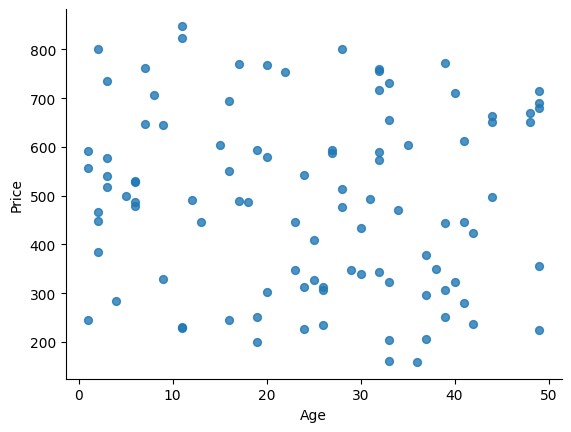

In [ ]:
from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Age', y='Price', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

# Model training

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset2
X = df[['Size', 'Bedrooms', 'Age']]
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train

,Size,Bedrooms,Age
55,58,2,11
88,249,2,11
26,70,3,24
42,104,3,23
69,213,1,16
...,...,...,...
60,141,3,34
71,153,1,3
14,153,1,6
92,160,1,31


In [ ]:
from sklearn.linear_model import LinearRegression

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
X_test

,Size,Bedrooms,Age
83,239,1,40
53,109,3,32
70,99,4,29
45,100,3,33
44,180,1,32
39,239,4,2
22,87,3,24
80,195,3,7
10,124,4,13
0,152,3,44


In [ ]:
# Predictions

y_pred = model.predict(X_test)
y_pred

array([722.77314286, 362.65225344, 348.19223146, 333.6954079 ,
       556.19349868, 816.91145744, 308.55102998, 664.01932493,
       449.74683942, 474.20366179, 311.09067952, 471.60774729,
       191.09367243, 743.36721929, 301.8858528 , 511.91916609,
       548.80995101, 213.17862965, 582.24948149, 295.73639087])

# Model evaluation

## Mean Squared Error (MSE)

* Measures the average squared difference between actual and predicted values.
* Lower MSE is better (closer to 0 means better accuracy).
* Our model has MSE = 299.05, meaning the model's predictions are quite close to the actual values.


## Mean Absolute Error (MAE)

* Measures the average absolute error between actual and predicted values.
* Unlike MSE, this metric is in the same unit as the target variable.

## Root Mean Squared Error (RMSE)

* Similar to MSE, but takes the square root, making it interpretable in the same unit as the target.
* Lower RMSE indicates better accuracy.

## R² Score (Coefficient of Determination)

* Measures how well the model explains the variance in the dependent variable.
* Ranges from 0 to 1, where 1 means perfect prediction and 0 means no predictive power.
* A value **less than 0 means** that the model is worse than the simple average (i.e. using the average price as a prediction would be better than this model).
* In our case, R² = 0.99, meaning the model explains 99% of the variation in house prices.

# Understanding MAE, MSE, and RMSE with an example

## **Given Data:**
- **Actual Prices:** `[100, 150, 200, 250, 300]`
- **Predicted Prices:** `[110, 140, 195, 260, 290]`

## **Step-by-step Error Calculation:**

$$
\text{Errors} = \text{Actual} - \text{Predicted} = [-10, 10, 5, -10, 10]
$$



## **1. Mean Absolute Error (MAE)**

$$
MAE = \frac{(|-10| + |10| + |5| + |-10| + |10|)}{5} = \frac{45}{5} = 9.0
$$

**MAE** averages the absolute errors, providing an interpretable metric in the same unit as the target variable.



## **2. Mean Squared Error (MSE)**

$$
MSE = \frac{(-10)^2 + (10)^2 + (5)^2 + (-10)^2 + (10)^2}{5} = \frac{850}{5} = 85.0
$$

**MSE** squares the errors, making large errors more influential in the final value.



## **3. Root Mean Squared Error (RMSE)**
$$
RMSE = \sqrt{85.0} = 9.22
$$
**RMSE** is similar to MSE but takes the square root to bring the error back to the original unit.



## **Key Differences:**
| Metric  | Sensitivity to Large Errors | Interpretability |
|---------|----------------------------|------------------|
| **MAE**  | Lower  | Easy to interpret (same unit as the target) |
| **MSE**  | Higher (due to squaring) | Harder to interpret due to squared units |
| **RMSE** | Higher (similar to MSE) | More interpretable than MSE |

**Summary:**  
- **MAE** gives an average error magnitude in the same unit as the output.  
- **MSE** penalizes larger errors more due to squaring.  
- **RMSE** is similar to MSE but is more interpretable in the original units.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Show evaluation results
mse, r2

(299.05196760159447, 0.9903104178419005)

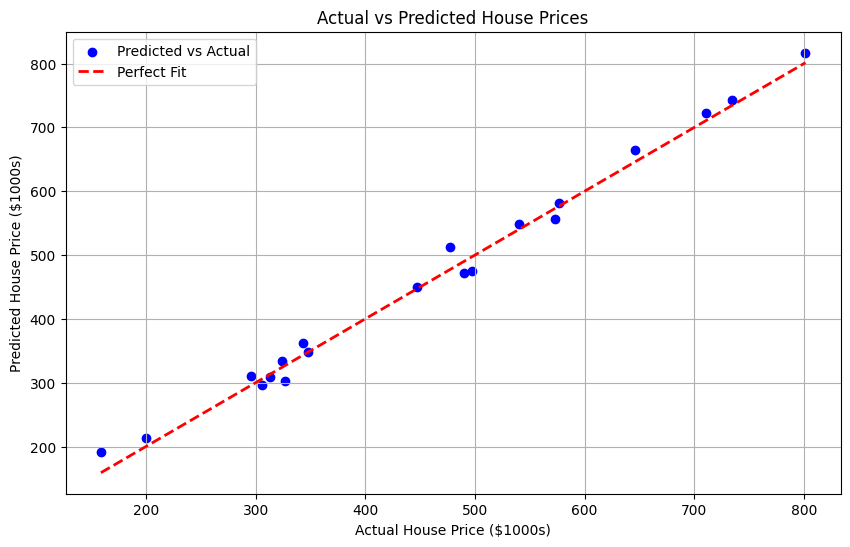

In [ ]:
# Plot the actual vs. predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed', linewidth=2, label='Perfect Fit')

plt.xlabel("Actual House Price ($1000s)")
plt.ylabel("Predicted House Price ($1000s)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.predict([[-2000, 10, 5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-5927.4574914])